Plots for Labbate et al., 2026 paper

Plot for omnigenity and $\eta$ definition figure

In [2]:
import time

import numpy as np

from firm3d.field.boozermagneticfield import (
    InterpolatedBoozerField,
    BoozerAnalytic,
)
from firm3d.field.trajectory_helpers import TrappedPoincare
from firm3d.util.constants import (
    ALPHA_PARTICLE_CHARGE,
    ALPHA_PARTICLE_MASS,
    FUSION_ALPHA_PARTICLE_ENERGY,
)
from firm3d.util.functions import in_github_actions, proc0_print, setup_logging
from firm3d.util.mpi import comm_size, comm_world, verbose

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
FontSize = 18
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

In [4]:
rho_plot = 0.5
num_points = 20  # sqrt(points)
theta_plot = np.linspace(0, 2 * np.pi, num_points)
n_field_periods = 1  # number of toroidal field periods to show in zeta
eq = "wout_agmd6_20230306_000_000000.nc"
M = 0  # |B| contour helicity (QI: M=0, N=nfp); N is set when loading eq

In [5]:
in_github_actions = False
resolution = 10 if in_github_actions else 48  # Resolution for field interpolation
nParticles = 50 if in_github_actions else 5000  # Number of particles to trace
reltol = 1e-4 if in_github_actions else 1e-8  # Relative tolerance for the ODE solver
abstol = 1e-4 if in_github_actions else 1e-8  # Absolute tolerance for the ODE solver
order = 3  # Order for radial interpolation
degree = 3  # Degree for 3d interpolation
tmax = 1e-4 if in_github_actions else 1e-2  # Time for integration
ns_interp = resolution
ntheta_interp = resolution
nzeta_interp = resolution

dt_save = 1e-7  # Time interval for saving trajectory points

In [6]:
from netCDF4 import Dataset

with Dataset(eq) as data:
    N = int(data.variables["nfp"][()])

field = InterpolatedBoozerField.from_booz_xform(
    eq,
    degree=order,
    ns=ns_interp,
    ntheta=ntheta_interp,
    nzeta=nzeta_interp,
    helicity_M=M,
    helicity_N=N,
    comm=comm_world,
)
assert field.nfp == N

About to try reading VMEC wout file wout_agmd6_20230306_000_000000.nc
Read ns=51, mpol=6, ntor=6, mnmax=72, mnmax_nyq=162


In [7]:
# Parameters for the η-definition figure are read from `field` in the next cell.
print(f"Using QS-filtered field: nfp={field.nfp}, s={rho_plot}")


Using QS-filtered field: nfp=6, s=0.5


In [8]:
# Landreman & Catto (2012) omnigenous field (M=0, N=nfp, QI-style contours)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter
from scipy.interpolate import RegularGridInterpolator

FontSize = 18
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 1

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)


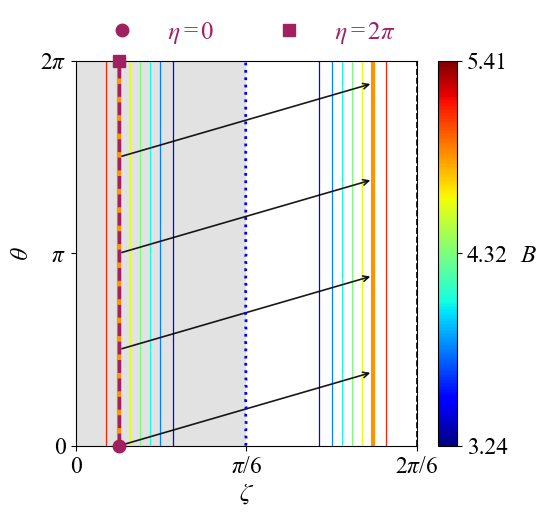

In [9]:
M = 0
N = field.nfp
Np = 1  # toroidal periods in the Landreman & Catto (2012) construction
s_plot = rho_plot  # Boozer radial coordinate (normalized toroidal flux)

# Read ι from the QS-filtered field at the plotted flux surface
field.set_points(np.array([[s_plot, 0.0, 0.0]]))
iota = float(field.iota()[0, 0])

zeta_period = 2 * np.pi / N
plot_zeta_min = 0.0
plot_zeta_max = zeta_period * n_field_periods

# |B| from the QS-filtered equilibrium (not the analytical L&C toy model)
nz, nt = 350, 350
zeta_lin = np.linspace(plot_zeta_min, plot_zeta_max, nz)
theta_lin = np.linspace(0, 2 * np.pi, nt)
ZZ, TT = np.meshgrid(zeta_lin, theta_lin)
field.set_points(
    np.column_stack([np.full(ZZ.size, s_plot), TT.ravel(), ZZ.ravel()])
)
B_grid = field.modB().reshape(ZZ.shape)
B_plot = B_grid

B_min = np.nanmin(B_plot)
B_max_plot = np.nanmax(B_plot)
n_contours_per_period = 7  # |B| contour lines per field period in ζ
period_levels = np.linspace(B_min, B_max_plot, n_contours_per_period + 2)[1:-1]
bold_B = period_levels[-2]
levels = period_levels
bold_lw = 3.0
linewidths = [bold_lw if np.any(np.isclose(lv, bold_B)) else 0.9 for lv in levels]
eta_color = "#A02060"  # dark pink for η markers, labels, and bold-|B| overlay

interp_B = RegularGridInterpolator(
    (theta_lin, zeta_lin), B_grid, method="linear", bounds_error=False, fill_value=np.nan
)

def zeta_crossings_at_B(theta_val, B_level, z_min, z_max):
    """Zeta values where the contour B=B_level crosses a horizontal theta line."""
    z_fine = np.linspace(z_min, z_max, 2000)
    pts = np.stack([np.full_like(z_fine, theta_val), z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - B_level
    crossings = []
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            z_c = z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
            crossings.append(z_c)
    return sorted(crossings)

def zeta_contour_branch(theta_vals, B_level, z_min, z_max, branch="left"):
    """Trace one branch of a |B| contour by picking a zeta crossing at each theta."""
    z_out = np.full(theta_vals.shape, np.nan)
    for i, theta_val in enumerate(theta_vals):
        crossings = zeta_crossings_at_B(theta_val, B_level, z_min, z_max)
        if not crossings:
            continue
        z_out[i] = crossings[0] if branch == "left" else crossings[-1]
    return z_out

def zeta_argmin_B(theta_vals, z_min, z_max):
    """At each theta, return zeta that minimizes |B| in the field period."""
    z_fine = np.linspace(z_min, z_max, 2000)
    z_out = np.empty(theta_vals.shape)
    for i, theta_val in enumerate(theta_vals):
        pts = np.stack([np.full_like(z_fine, theta_val), z_fine], axis=-1)
        z_out[i] = z_fine[np.argmin(interp_B(pts))]
    return z_out

def zeta_bold_crossings_at_theta_y(theta_val, z_min, z_max):
    return zeta_crossings_at_B(theta_val, bold_B, z_min, z_max)

def next_bold_zeta_on_field_line(alpha, z_start, z_max):
    """Traces along the field line to find the next crossing with the bold B contour."""
    z_fine = np.linspace(z_start + 1e-3, z_max, 2000)
    theta_fine = alpha + iota * z_fine
    theta_fine_wrapped = theta_fine % (2 * np.pi)
    pts = np.stack([theta_fine_wrapped, z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - bold_B
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            return z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
    return None

# Minimum-|B| curve on the plot grid (left boundary of the shaded well side)
zeta_Bmin_vs_theta = zeta_argmin_B(theta_lin, plot_zeta_min, plot_zeta_max)
theta_curve = np.linspace(0, 2 * np.pi, 400)
zeta_Bmin_curve = np.interp(theta_curve, theta_lin, zeta_Bmin_vs_theta)

fig, ax = plt.subplots(figsize=(5.5, 5.0))

# Shade only to the left of the minimum-|B| curve (one side of the magnetic well)
well_shade = ZZ < zeta_Bmin_vs_theta[:, np.newaxis]
branch_shade = np.ma.masked_where(~well_shade, np.ones_like(ZZ))
ax.contourf(
    ZZ,
    TT,
    branch_shade,
    levels=[0.5, 1.5],
    colors=["0.75"],
    alpha=0.45,
    antialiased=False,
)

cs = ax.contour(
    ZZ,
    TT,
    B_plot,
    levels=levels,
    cmap="jet",
    vmin=B_min,
    vmax=B_max_plot,
    linewidths=linewidths,
)

# Dashed overlay: left branch of the bold |B| contour from the equilibrium
zeta_bold_left = zeta_contour_branch(
    theta_curve, bold_B, plot_zeta_min, plot_zeta_max, branch="left"
)
valid = np.isfinite(zeta_bold_left)
ax.plot(
    zeta_bold_left[valid],
    theta_curve[valid],
    color=eta_color,
    ls="--",
    lw=bold_lw - 0.5,
    zorder=9,
)

# Dotted overlay: minimum |B| in this field period (valley at each theta)
ax.plot(zeta_Bmin_curve, theta_curve, "b:", lw=2.0, zorder=9)

# Field-period separators at ζ = k (2π / nfp), including ζ = 0
k_sep_lo = int(np.floor(plot_zeta_min / zeta_period - 1e-9))
k_sep_hi = int(np.ceil(plot_zeta_max / zeta_period + 1e-9))
zeta_seps = {k * zeta_period for k in range(k_sep_lo, k_sep_hi + 1)}
if plot_zeta_min <= 0.0 <= plot_zeta_max:
    zeta_seps.add(0.0)
for zeta_sep in sorted(zeta_seps):
    ax.axvline(zeta_sep, color="k", ls="--", lw=1.2, zorder=7)

# Magnetic field lines: straight in Boozer (θ, ζ) with slope ι
n_field_lines = 5
theta_starts = np.linspace(0, 2 * np.pi, n_field_lines)

for theta_start in theta_starts:
    crossings = zeta_bold_crossings_at_theta_y(theta_start, plot_zeta_min, plot_zeta_max)
    if not crossings:
        continue

    z_start = crossings[0]
    alpha = theta_start - iota * z_start

    z_end = next_bold_zeta_on_field_line(alpha, z_start, plot_zeta_max + 2.0)

    if z_end is not None:
        theta_end = alpha + iota * z_end
        ax.annotate(
            "",
            xy=(z_end, theta_end),
            xytext=(z_start, theta_start),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.2, alpha=0.9),
            zorder=8,
        )

cross_0 = zeta_bold_crossings_at_theta_y(0, plot_zeta_min, plot_zeta_max)
if cross_0:
    ax.plot(
        cross_0[0],
        0,
        marker="o",
        markersize=9,
        color=eta_color,
        linestyle="None",
        label=r"$\eta = 0$",
        zorder=10,
        clip_on=False,
    )

cross_2pi = zeta_bold_crossings_at_theta_y(2 * np.pi, plot_zeta_min, plot_zeta_max)
if cross_2pi:
    ax.plot(
        cross_2pi[0],
        2 * np.pi,
        marker="s",
        markersize=9,
        color=eta_color,
        linestyle="None",
        label=r"$\eta = 2\pi$",
        zorder=10,
        clip_on=False,
    )

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False,
    labelcolor=eta_color,
    prop={"family": "Times New Roman", "size": FontSize},
)

ax.set_xlim(plot_zeta_min, plot_zeta_max)
ax.set_ylim(0, 2 * np.pi)

ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

ax.set_xticks([0, np.pi / 6, 2 * np.pi / 6])
ax.set_xticklabels(["0", r"$\pi / 6$", r"$2\pi / 6$"])

ax.set_xlabel(r"$\zeta$", **label_kw)
ax.set_ylabel(r"$\theta$", **label_kw)
ax.set_aspect("auto")
ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

cbar_ticks = np.linspace(B_min, B_max_plot, 3)
b_norm = Normalize(vmin=B_min, vmax=B_max_plot)
cbar = fig.colorbar(
    ScalarMappable(cmap="jet", norm=b_norm),
    ax=ax,
    ticks=cbar_ticks,
)
cbar.set_ticks(cbar_ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.ax.tick_params(labelsize=tick_labelsize)
for label in cbar.ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
cbar.set_label(r"$B$", rotation=0, labelpad=15, y=0.525, **label_kw)

# plt.savefig("figures/omnigenity_and_eta_definition.pdf", dpi=300)
# plt.show()


## η-definition figure from a pyQIC near-axis QI field

Set `stel` in the next cell, then run the plotting cell. Uses `stel.B_mag(..., Boozer_toroidal=True)` and `stel.iota` directly.

**Important:** use an omnigenous (`omn=True`) pyQIC configuration such as `"QI"` or `"QI Jorge"`. Examples like `"r2 section 5.2"` are *not* QI — they have |B| independent of ζ at leading order, which produces horizontal contours and breaks the overlay logic.

In [10]:
from qic import Qic

# --- configure the pyQIC stellarator here ---
# Omnigenous examples: "QI", "QI Jorge", "QI r1 Jorge"
# NOT QI (|B| ~ f(θ) only): "r2 section 5.2", "r1 section 5.1", ...
stel = Qic.from_paper("QI")
r_plot = 0.1  # near-axis minor radius passed to pyQIC B_mag(r, ...)

print(
    f"pyQIC: nfp={stel.nfp}, omn={getattr(stel, 'omn', None)}, "
    f"iota={stel.iota:.4f}, order={stel.order}, r_plot={r_plot}"
)


pyQIC: nfp=1, omn=True, iota=0.7166, order=r1, r_plot=0.1


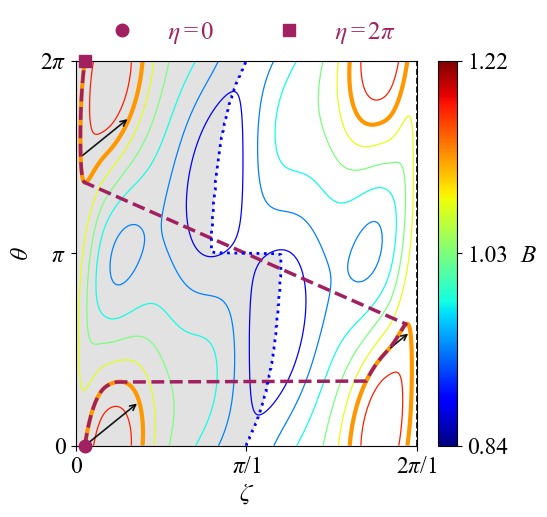

In [11]:
# Plot η-definition figure from a pyQIC near-axis QI field (requires `stel`, cell above)
M = 0
N = stel.nfp
Np = 1
iota = float(stel.iota)

zeta_period = 2 * np.pi / N
plot_zeta_min = 0.0
plot_zeta_max = zeta_period * n_field_periods

nz, nt = 350, 350
zeta_lin = np.linspace(plot_zeta_min, plot_zeta_max, nz)
theta_lin = np.linspace(0, 2 * np.pi, nt)
ZZ, TT = np.meshgrid(zeta_lin, theta_lin)
B_grid = stel.B_mag(r_plot, TT, ZZ, Boozer_toroidal=True)
B_plot = np.asarray(B_grid, dtype=float)

zeta_var = np.mean(np.std(B_plot, axis=1))
theta_var = np.mean(np.std(B_plot, axis=0))
if zeta_var < 0.01 * theta_var:
    raise ValueError(
        f"|B| has almost no ζ variation (zeta_std={zeta_var:.2e}, "
        f"theta_std={theta_var:.2e}). Choose an omnigenous pyQIC config "
        f"(e.g. Qic.from_paper('QI')), not a quasi-symmetric example."
    )

B_min = np.nanmin(B_plot)
B_max_plot = np.nanmax(B_plot)
n_contours_per_period = 7
period_levels = np.linspace(B_min, B_max_plot, n_contours_per_period + 2)[1:-1]
bold_B = period_levels[-2]
levels = period_levels
bold_lw = 3.0
linewidths = [bold_lw if np.any(np.isclose(lv, bold_B)) else 0.9 for lv in levels]
eta_color = "#A02060"

interp_B = RegularGridInterpolator(
    (theta_lin, zeta_lin), B_grid, method="linear", bounds_error=False, fill_value=np.nan
)

def zeta_crossings_at_B(theta_val, B_level, z_min, z_max):
    z_fine = np.linspace(z_min, z_max, 2000)
    pts = np.stack([np.full_like(z_fine, theta_val), z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - B_level
    crossings = []
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            z_c = z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
            crossings.append(z_c)
    return sorted(crossings)

def zeta_contour_branch(theta_vals, B_level, z_min, z_max, branch="left"):
    z_out = np.full(theta_vals.shape, np.nan)
    for i, theta_val in enumerate(theta_vals):
        crossings = zeta_crossings_at_B(theta_val, B_level, z_min, z_max)
        if not crossings:
            continue
        z_out[i] = crossings[0] if branch == "left" else crossings[-1]
    return z_out

def zeta_argmin_B(theta_vals, z_min, z_max):
    z_fine = np.linspace(z_min, z_max, 2000)
    z_out = np.empty(theta_vals.shape)
    for i, theta_val in enumerate(theta_vals):
        pts = np.stack([np.full_like(z_fine, theta_val), z_fine], axis=-1)
        z_out[i] = z_fine[np.argmin(interp_B(pts))]
    return z_out

def zeta_bold_crossings_at_theta_y(theta_val, z_min, z_max):
    return zeta_crossings_at_B(theta_val, bold_B, z_min, z_max)

def next_bold_zeta_on_field_line(alpha, z_start, z_max):
    z_fine = np.linspace(z_start + 1e-3, z_max, 2000)
    theta_fine = alpha + iota * z_fine
    theta_fine_wrapped = theta_fine % (2 * np.pi)
    pts = np.stack([theta_fine_wrapped, z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - bold_B
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            return z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
    return None

zeta_Bmin_vs_theta = zeta_argmin_B(theta_lin, plot_zeta_min, plot_zeta_max)
theta_curve = np.linspace(0, 2 * np.pi, 400)
zeta_Bmin_curve = np.interp(theta_curve, theta_lin, zeta_Bmin_vs_theta)

fig, ax = plt.subplots(figsize=(5.5, 5.0))

well_shade = ZZ < zeta_Bmin_vs_theta[:, np.newaxis]
branch_shade = np.ma.masked_where(~well_shade, np.ones_like(ZZ))
ax.contourf(
    ZZ,
    TT,
    branch_shade,
    levels=[0.5, 1.5],
    colors=["0.75"],
    alpha=0.45,
    antialiased=False,
)

ax.contour(
    ZZ,
    TT,
    B_plot,
    levels=levels,
    cmap="jet",
    vmin=B_min,
    vmax=B_max_plot,
    linewidths=linewidths,
)

zeta_bold_left = zeta_contour_branch(
    theta_curve, bold_B, plot_zeta_min, plot_zeta_max, branch="left"
)
valid = np.isfinite(zeta_bold_left)
ax.plot(
    zeta_bold_left[valid],
    theta_curve[valid],
    color=eta_color,
    ls="--",
    lw=bold_lw - 0.5,
    zorder=9,
)

ax.plot(zeta_Bmin_curve, theta_curve, "b:", lw=2.0, zorder=9)

k_sep_lo = int(np.floor(plot_zeta_min / zeta_period - 1e-9))
k_sep_hi = int(np.ceil(plot_zeta_max / zeta_period + 1e-9))
zeta_seps = {k * zeta_period for k in range(k_sep_lo, k_sep_hi + 1)}
if plot_zeta_min <= 0.0 <= plot_zeta_max:
    zeta_seps.add(0.0)
for zeta_sep in sorted(zeta_seps):
    ax.axvline(zeta_sep, color="k", ls="--", lw=1.2, zorder=7)

n_field_lines = 5
theta_starts = np.linspace(0, 2 * np.pi, n_field_lines)
for theta_start in theta_starts:
    crossings = zeta_bold_crossings_at_theta_y(theta_start, plot_zeta_min, plot_zeta_max)
    if not crossings:
        continue
    z_start = crossings[0]
    alpha = theta_start - iota * z_start
    z_end = next_bold_zeta_on_field_line(alpha, z_start, plot_zeta_max + 2.0)
    if z_end is not None:
        theta_end = alpha + iota * z_end
        ax.annotate(
            "",
            xy=(z_end, theta_end),
            xytext=(z_start, theta_start),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.2, alpha=0.9),
            zorder=8,
        )

cross_0 = zeta_bold_crossings_at_theta_y(0, plot_zeta_min, plot_zeta_max)
if cross_0:
    ax.plot(
        cross_0[0], 0,
        marker="o", markersize=9, color=eta_color,
        linestyle="None", label=r"$\eta = 0$", zorder=10, clip_on=False,
    )

cross_2pi = zeta_bold_crossings_at_theta_y(2 * np.pi, plot_zeta_min, plot_zeta_max)
if cross_2pi:
    ax.plot(
        cross_2pi[0], 2 * np.pi,
        marker="s", markersize=9, color=eta_color,
        linestyle="None", label=r"$\eta = 2\pi$", zorder=10, clip_on=False,
    )

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False,
    labelcolor=eta_color,
    prop={"family": "Times New Roman", "size": FontSize},
)

ax.set_xlim(plot_zeta_min, plot_zeta_max)
ax.set_ylim(0, 2 * np.pi)
ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
ax.set_xticks([0, np.pi / N, 2 * np.pi / N])
ax.set_xticklabels(["0", rf"$\pi / {N}$", rf"$2\pi / {N}$"])
ax.set_xlabel(r"$\zeta$", **label_kw)
ax.set_ylabel(r"$\theta$", **label_kw)
ax.set_aspect("auto")
ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

cbar_ticks = np.linspace(B_min, B_max_plot, 3)
b_norm = Normalize(vmin=B_min, vmax=B_max_plot)
cbar = fig.colorbar(
    ScalarMappable(cmap="jet", norm=b_norm),
    ax=ax,
    ticks=cbar_ticks,
)
cbar.set_ticks(cbar_ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.ax.tick_params(labelsize=tick_labelsize)
for label in cbar.ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
cbar.set_label(r"$B$", rotation=0, labelpad=15, y=0.525, **label_kw)

# plt.savefig("figures/omnigenity_and_eta_definition_pyQIC.pdf", dpi=300)
# plt.show()


## η-definition figure from the Landreman & Catto (2012) analytical QI field

Perfectly omnigenous model with \(B = B_0(1 + \varepsilon + \varepsilon\cos\eta)\) and the forward map \((\eta, \tilde\theta) \to (\theta, \zeta)\) from eqs. (72)–(73). Set parameters in the next cell, then run the plot cell.

In [12]:
from scipy.interpolate import griddata

# --- Landreman & Catto (2012) omnigenous QI model parameters ---
lc_N = 6              # QI helicity: M=0, N=nfp
lc_iota = 1.05        # rotational transform ι
lc_epsilon = 0.072    # well depth ε in B = B_check(1 + ε + ε cos η)
lc_B_check = 1.0      # reference |B| at η = π
lc_s_xy_scale = 0.4   # amplitude in s_xy(x, y) = scale * x * sin(y)

print(
    f"L&C 2012 QI: N={lc_N}, ι={lc_iota}, ε={lc_epsilon}, "
    f"B_min={lc_B_check:.3f}, B_max={lc_B_check*(1+2*lc_epsilon):.3f}"
)


L&C 2012 QI: N=6, ι=1.05, ε=0.072, B_min=1.000, B_max=1.144


In [13]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.14, right=0.90, bottom=0.14, top=0.88) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)

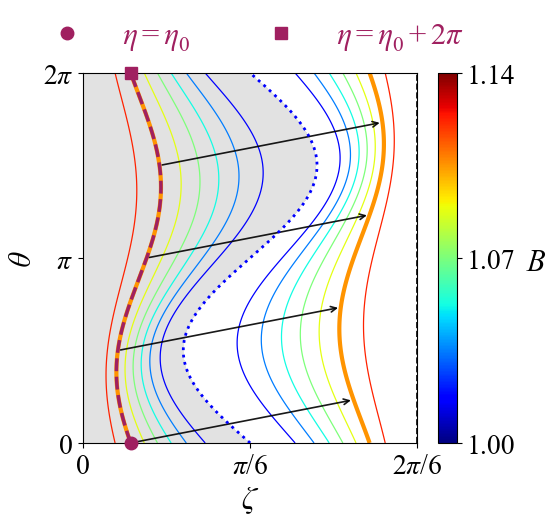

In [14]:
# Plot η-definition figure from Landreman & Catto (2012) analytical omnigenous QI field
M = 0
N = lc_N
Np = 1
iota = lc_iota
epsilon = lc_epsilon
B_check = lc_B_check

def s_xy(x, y):
    return lc_s_xy_scale * x * np.sin(y)

def D_x(x):
    return np.pi - x

iota_tilde = iota / ((N - iota * M) * Np)

def zeta_tilde_from_eta(eta, theta_tilde):
    """Forward map ζ̃(η, θ̃) from Landreman & Catto (2012), eqs. (72)–(73)."""
    out = np.empty(np.broadcast(eta, theta_tilde).shape, dtype=float)
    mask = eta <= np.pi
    etap = 2 * np.pi - eta
    out[mask] = (
        np.pi
        - s_xy(eta[mask], theta_tilde[mask] + iota_tilde * D_x(eta[mask]))
        - D_x(eta[mask])
    )
    out[~mask] = (
        np.pi
        + s_xy(etap[~mask], -theta_tilde[~mask] + iota_tilde * D_x(etap[~mask]))
        + D_x(etap[~mask])
    )
    return out

def B_from_eta(eta):
    return B_check * (1 + epsilon + epsilon * np.cos(eta))

# Forward map (η, θ̃) → (θ, ζ)
neta, ntheta = 240, 240
eta_vals = np.linspace(0, 2 * np.pi, neta, endpoint=True)
theta_tilde_vals = np.linspace(0, 2 * np.pi, ntheta, endpoint=True)
ETA, TH = np.meshgrid(eta_vals, theta_tilde_vals)
zeta_tilde = zeta_tilde_from_eta(ETA, TH)
theta = TH
zeta = (zeta_tilde + M * theta) / (N * Np)
B = B_from_eta(ETA)

zeta_period = 2 * np.pi / N
plot_zeta_min = 0.0
plot_zeta_max = zeta_period * n_field_periods

# Tile by field period: B(θ, ζ + k ζ_period) = B(θ, ζ) when M = 0
pts_z, pts_t, pts_B, pts_eta = [], [], [], []
for k in range(-1, n_field_periods):
    zeta_k = zeta + k * zeta_period
    in_tile = (
        (zeta_k >= plot_zeta_min)
        & (zeta_k <= plot_zeta_max)
        & (theta >= 0)
        & (theta <= 2 * np.pi)
    )
    pts_z.append(zeta_k[in_tile].ravel())
    pts_t.append(theta[in_tile].ravel())
    pts_B.append(B[in_tile].ravel())
    pts_eta.append(ETA[in_tile].ravel())
pts_z = np.concatenate(pts_z)
pts_t = np.concatenate(pts_t)
pts_B = np.concatenate(pts_B)
pts_eta = np.concatenate(pts_eta)

nz, nt = 350, 350
zeta_lin = np.linspace(plot_zeta_min, plot_zeta_max, nz)
theta_lin = np.linspace(0, 2 * np.pi, nt)
ZZ, TT = np.meshgrid(zeta_lin, theta_lin)
B_grid = griddata((pts_z, pts_t), pts_B, (ZZ, TT), method="linear")
eta_grid = griddata((pts_z, pts_t), pts_eta, (ZZ, TT), method="linear")
B_plot = B_grid

B_min = np.nanmin(B_plot)
B_max_plot = np.nanmax(B_plot)
n_contours_per_period = 7
period_levels = np.linspace(B_min, B_max_plot, n_contours_per_period + 2)[1:-1]
bold_B = period_levels[-2]
levels = period_levels
bold_lw = 3.0
linewidths = [bold_lw if np.any(np.isclose(lv, bold_B)) else 0.9 for lv in levels]
eta_color = "#A02060"

interp_B = RegularGridInterpolator(
    (theta_lin, zeta_lin), B_grid, method="linear", bounds_error=False, fill_value=np.nan
)

def zeta_crossings_at_B(theta_val, B_level, z_min, z_max):
    z_fine = np.linspace(z_min, z_max, 2000)
    pts = np.stack([np.full_like(z_fine, theta_val), z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - B_level
    crossings = []
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            z_c = z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
            crossings.append(z_c)
    return sorted(crossings)

def zeta_bold_crossings_at_theta_y(theta_val, z_min, z_max):
    return zeta_crossings_at_B(theta_val, bold_B, z_min, z_max)

def next_bold_zeta_on_field_line(alpha, z_start, z_max):
    z_fine = np.linspace(z_start + 1e-3, z_max, 2000)
    theta_fine = alpha + iota * z_fine
    theta_fine_wrapped = theta_fine % (2 * np.pi)
    pts = np.stack([theta_fine_wrapped, z_fine], axis=-1)
    B_vals = interp_B(pts)
    diff = B_vals - bold_B
    for i in range(len(diff) - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i + 1]):
            continue
        if diff[i] * diff[i + 1] <= 0:
            return z_fine[i] + (z_fine[i + 1] - z_fine[i]) * (-diff[i]) / (diff[i + 1] - diff[i])
    return None

theta_curve = np.linspace(0, 2 * np.pi, 400)

fig, ax = plt.subplots(figsize=(5.5, 5.0))

# Shade the η < π branch (exact from the L&C forward map)
branch_shade = np.ma.masked_where(~(eta_grid < np.pi), np.ones_like(eta_grid))
ax.contourf(
    ZZ, TT, branch_shade,
    levels=[0.5, 1.5], colors=["0.75"], alpha=0.45, antialiased=False,
)

ax.contour(
    ZZ, TT, B_plot, levels=levels, cmap="jet",
    vmin=B_min, vmax=B_max_plot, linewidths=linewidths,
)

# Dashed: η = const branch on the left bold |B| contour (analytical L&C curve)
eta_bold = np.arccos(np.clip((bold_B / B_check - 1 - epsilon) / epsilon, -1, 1))
eta_bold_line = np.full_like(theta_curve, eta_bold)
zeta_bold = (zeta_tilde_from_eta(eta_bold_line, theta_curve) + M * theta_curve) / (N * Np)
ax.plot(zeta_bold, theta_curve, color=eta_color, ls="--", lw=bold_lw - 0.5, zorder=9)

# Dotted: η = π (B = B_min) from the analytical map
eta_Bmin_line = np.full_like(theta_curve, np.pi)
zeta_Bmin = (zeta_tilde_from_eta(eta_Bmin_line, theta_curve) + M * theta_curve) / (N * Np)
ax.plot(zeta_Bmin, theta_curve, "b:", lw=2.0, zorder=9)

# Field-period separators
k_sep_lo = int(np.floor(plot_zeta_min / zeta_period - 1e-9))
k_sep_hi = int(np.ceil(plot_zeta_max / zeta_period + 1e-9))
for k in range(k_sep_lo, k_sep_hi + 1):
    ax.axvline(k * zeta_period, color="k", ls="--", lw=1.2, zorder=7)

# Magnetic field lines: θ = α + ιζ
n_field_lines = 5
for theta_start in np.linspace(0, 2 * np.pi, n_field_lines):
    crossings = zeta_bold_crossings_at_theta_y(theta_start, plot_zeta_min, plot_zeta_max)
    if not crossings:
        continue
    z_start = crossings[0]
    alpha = theta_start - iota * z_start
    z_end = next_bold_zeta_on_field_line(alpha, z_start, plot_zeta_max + 2.0)
    if z_end is not None:
        theta_end = alpha + iota * z_end
        ax.annotate(
            "", xy=(z_end, theta_end), xytext=(z_start, theta_start),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.2, alpha=0.9), zorder=8,
        )

cross_0 = zeta_bold_crossings_at_theta_y(0, plot_zeta_min, plot_zeta_max)
if cross_0:
    ax.plot(cross_0[0], 0, marker="o", markersize=9, color=eta_color,
            linestyle="None", label=r"$\eta = \eta_0$", zorder=10, clip_on=False)
cross_2pi = zeta_bold_crossings_at_theta_y(2 * np.pi, plot_zeta_min, plot_zeta_max)
if cross_2pi:
    ax.plot(cross_2pi[0], 2 * np.pi, marker="s", markersize=9, color=eta_color,
            linestyle="None", label=r"$\eta = \eta_0 + 2\pi$", zorder=10, clip_on=False)

ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=False,
    labelcolor=eta_color, prop={"family": "Times New Roman", "size": FontSize},
)
ax.set_xlim(plot_zeta_min, plot_zeta_max)
ax.set_ylim(0, 2 * np.pi)
ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
ax.set_xticks([0, np.pi / N, 2 * np.pi / N])
ax.set_xticklabels(["0", rf"$\pi / {N}$", rf"$2\pi / {N}$"])
ax.set_xlabel(r"$\zeta$", **label_kw)
ax.set_ylabel(r"$\theta$", **label_kw)
ax.set_aspect("auto")
ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

cbar_ticks = np.linspace(B_min, B_max_plot, 3)
b_norm = Normalize(vmin=B_min, vmax=B_max_plot)
cbar = fig.colorbar(ScalarMappable(cmap="jet", norm=b_norm), ax=ax, ticks=cbar_ticks)
cbar.set_ticks(cbar_ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar.ax.tick_params(labelsize=tick_labelsize)
for label in cbar.ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
cbar.set_label(r"$B$", rotation=0, labelpad=15, y=0.525, **label_kw)

apply_standard_axes(fig)

plt.savefig("figures/omnigenity_and_eta_definition_LC2012.pdf", dpi=300)
plt.show()
